In [1]:
from utils.cnn_utils.cnn_preprocessing_utils import CNNPreprocessor

In [2]:
cnn_preprocessor = CNNPreprocessor(sensors_path="../../../../data/ml/features_machine_and_movement_complete.csv", target_path="../../../../data/ml/targets_movement_complete.csv")

In [3]:
sensors_df, target_df = cnn_preprocessor.read_data()
sensors_df = cnn_preprocessor.feature_selection()
cnn_preprocessor.normalize_angle()

,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,2,0.022017,0.319825,0.363018,0.600159,0.372211
2,2,0.044033,0.319035,0.401244,0.560835,0.412939
3,2,0.066050,0.317768,0.438220,0.522651,0.452336
4,2,0.088067,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...
14558,318,0.902686,0.641596,0.373375,0.680266,0.314326
14559,318,0.924703,0.640550,0.372634,0.680719,0.313536
14560,318,0.946720,0.640334,0.374073,0.679194,0.315070
14561,318,0.968736,0.641037,0.377992,0.675413,0.319245


In [4]:
sensor_data = sensors_df[sensors_df["Experiment_ID"]==2].iloc[:,1:]

# Granger causality: 
The influence curve is a time-localized measure of how strongly past sensor readings “cause” changes in the target sensor according to Granger causality.

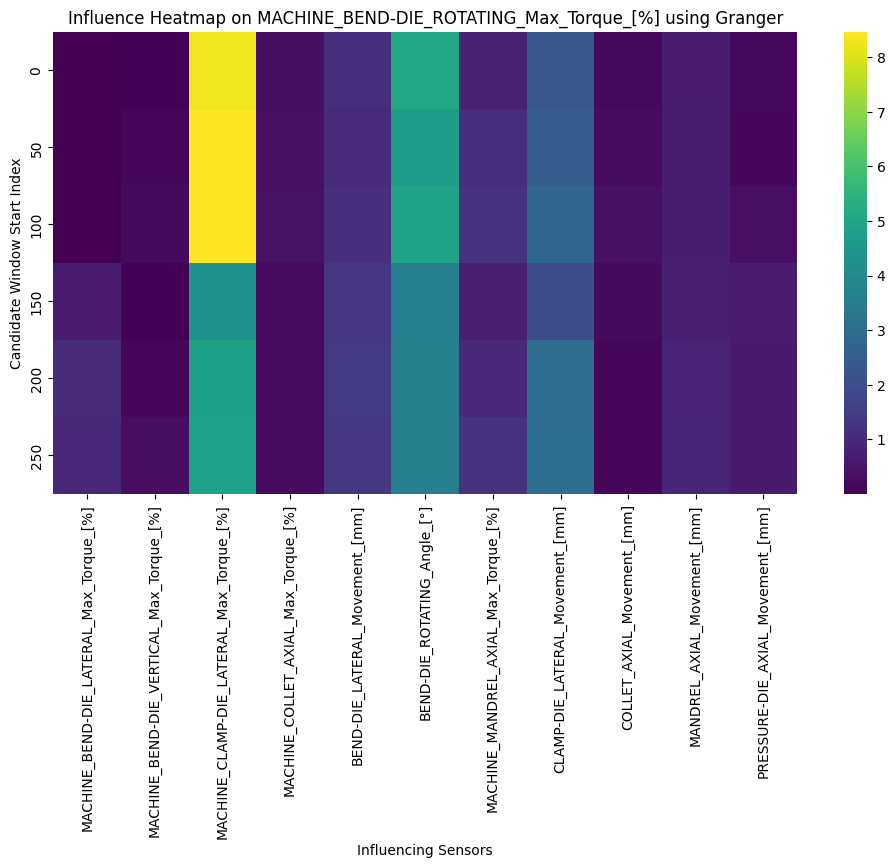

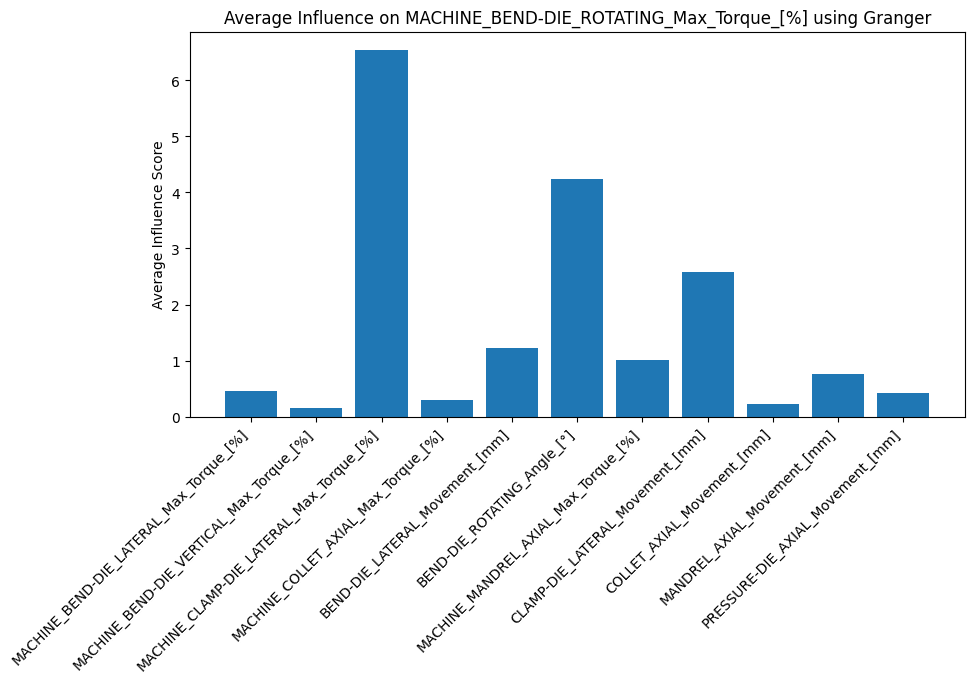

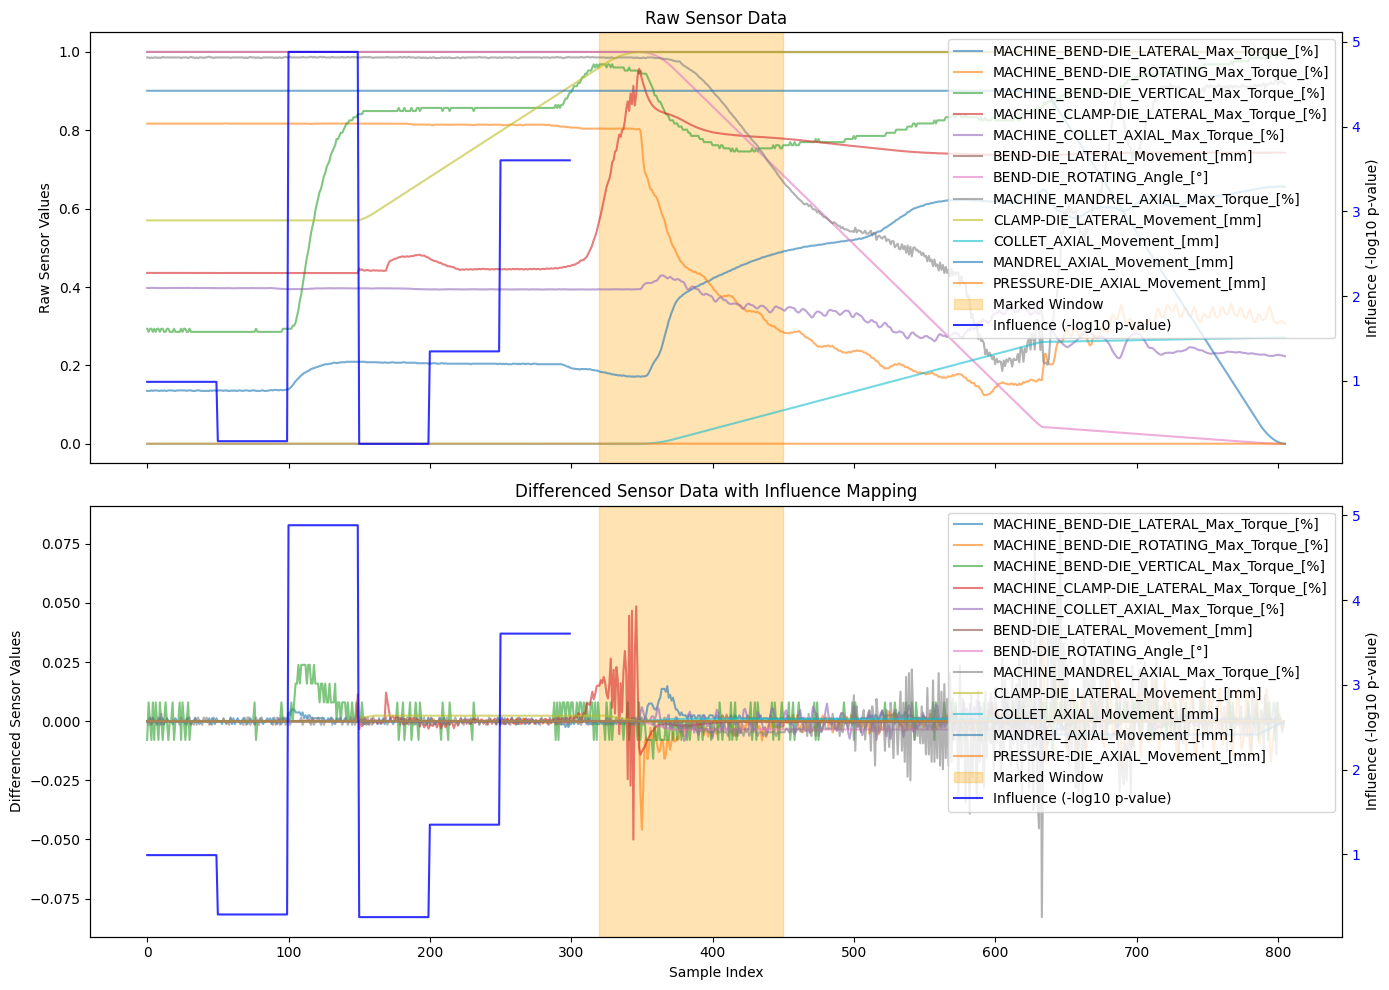

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# VAR / Granger
from statsmodels.tsa.api import VAR

# Transfer Entropy
from pyinform.transferentropy import transfer_entropy

# PCMCI
from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import pcmci

from dtaidistance import dtw
# -------------------------
# 0. Choose method
# -------------------------
method = "granger"  # options: "granger", "transfer_entropy", "cross_correlation", "dtw"

# -------------------------
# 1. Prepare data
# -------------------------
df = sensor_data.copy()
selected_columns = [
    'MACHINE_BEND-DIE_LATERAL_Max_Torque_[%]',
    'MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]',
    'MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%]',
    'MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%]',
    'MACHINE_COLLET_AXIAL_Max_Torque_[%]',
    # 'MACHINE_COLLET_ROTATING_Max_Torque_[%]',
    'BEND-DIE_LATERAL_Movement_[mm]', 
    'BEND-DIE_ROTATING_Angle_[°]',
    'MACHINE_MANDREL_AXIAL_Max_Torque_[%]',
    'CLAMP-DIE_LATERAL_Movement_[mm]', 
    'COLLET_AXIAL_Movement_[mm]',
    'MANDREL_AXIAL_Movement_[mm]', 
    'PRESSURE-DIE_AXIAL_Movement_[mm]'
]

df_subset = df[selected_columns]
df_diff = df_subset.diff().dropna()
x = np.arange(len(df_diff))

# -------------------------
# 2. Marked window
# -------------------------
effect_start, effect_end = 320, 450
target_col = 'MACHINE_BEND-DIE_ROTATING_Max_Torque_[%]'
target_window = df_diff.iloc[effect_start:effect_end]

# -------------------------
# 3. Candidate windows
# -------------------------
window_size = 50
step = 50
candidate_starts = range(0, effect_start - window_size + 1, step)

influence_matrix = []

for start in candidate_starts:
    candidate_window = df_diff.iloc[start:start + window_size]
    combined = pd.concat([candidate_window, target_window])

    row_scores = []
    for col in selected_columns:
        if col != target_col:
            try:
                if method == "granger":
                    combined = combined.reset_index(drop=True)
                    model = VAR(combined)

                    maxlags = min(3, (len(combined)-1)//len(selected_columns))
                    results = model.fit(maxlags=maxlags)
                    gc_test = results.test_causality(target_col, [col], kind='f')
                    row_scores.append(-np.log10(gc_test.pvalue))
                    
                elif method == "cross_correlation":
                    y_slice = target_window.iloc[:window_size, 0].values
                    x_vals = candidate_window[col].values
                    # take max absolute correlation with small lag window
                    max_corr = np.max([np.corrcoef(x_vals[:-lag], y_slice[lag:])[0,1] 
                                    for lag in range(1, min(5, len(x_vals)))])
                    row_scores.append(abs(max_corr))
                    
                elif method == "dtw":
                    y_slice = target_window.iloc[:window_size, 0].values
                    x_vals = candidate_window[col].values
                    dist = dtw.distance(x_vals, y_slice)
                    # smaller distance → higher influence, so invert
                    row_scores.append(1 / (dist + 1e-9))

                elif method == "transfer_entropy":
                    # Slice target to candidate length
                    y_slice = target_window.iloc[:window_size, 0]
                    x_disc = ((candidate_window[col] - candidate_window[col].min()) /
                              (candidate_window[col].max() - candidate_window[col].min() + 1e-9) * 10).astype(int)
                    y_disc = ((y_slice - y_slice.min()) /
                              (y_slice.max() - y_slice.min() + 1e-9) * 10).astype(int)
                    te = transfer_entropy(x_disc.values, y_disc.values, k=1)
                    row_scores.append(abs(te))

                elif method == "pcmci":
                    dataframe = pp.DataFrame(combined.values)
                    cond_ind_test = ParCorr()
                    pcmci_obj = pcmci.PCMCI(dataframe=dataframe, cond_ind_test=cond_ind_test)
                    results_pcmci = pcmci_obj.run_pcmci(tau_max=3, pc_alpha=0.05)
                    target_idx = list(combined.columns).index(target_col)
                    vals = results_pcmci['val_matrix'][:, :, target_idx]
                    row_scores.append(np.nanmean(np.abs(vals)))

            except:
                row_scores.append(np.nan)

    influence_matrix.append(row_scores)

influence_matrix = np.array(influence_matrix)

# -------------------------
# 4. Heatmap: influence per sensor and window
# -------------------------
influence_matrix_for_heatmap = np.nan_to_num(influence_matrix, nan=0)  # replace NaN with 0

plt.figure(figsize=(12,6))
sns.heatmap(
    influence_matrix_for_heatmap,
    xticklabels=[c for c in selected_columns if c != target_col],
    yticklabels=list(candidate_starts),
    cmap='viridis'
)
plt.xlabel("Influencing Sensors")
plt.ylabel("Candidate Window Start Index")
plt.title(f"Influence Heatmap on {target_col} using {method.capitalize()}")
plt.show()


# -------------------------
# 5. Bar plot: average influence per sensor
# -------------------------
avg_influence = np.nanmean(influence_matrix, axis=0)

plt.figure(figsize=(10,5))
plt.bar([c for c in selected_columns if c != target_col], avg_influence)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Average Influence Score")
plt.title(f"Average Influence on {target_col} using {method.capitalize()}")
plt.show()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,10), sharex=True)
influence_mapped = np.full(len(df_diff), np.nan)
for score, start in zip(row_scores, candidate_starts):
    influence_mapped[start:start+window_size] = score  # fill each window with same score

# --- Panel 1: raw data ---
for col in df_subset.columns:
    ax1.plot(np.arange(len(sensor_data)), sensor_data[col].values, label=col, alpha=0.6)  # use col, not sensor_data.columns
ax1.axvspan(effect_start, effect_end, color='orange', alpha=0.3, label='Marked Window')

ax_influence = ax1.twinx()
ax_influence.plot(x, influence_mapped, color='blue', alpha=0.8, label='Influence (-log10 p-value)')
ax_influence.set_ylabel("Influence (-log10 p-value)")
ax_influence.tick_params(axis='y', labelcolor='blue')

ax1.set_ylabel("Raw Sensor Values")
ax1.set_title("Raw Sensor Data")

# Combine legends from ax1 and twin axis
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax_influence.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')


# --- Panel 2: differenced + influence ---
for col in df_diff.columns:
    ax2.plot(x, df_diff[col], label=col, alpha=0.6)
ax2.axvspan(effect_start, effect_end, color='orange', alpha=0.3, label='Marked Window')

ax_influence = ax2.twinx()
ax_influence.plot(x, influence_mapped, color='blue', alpha=0.8, label='Influence (-log10 p-value)')
ax_influence.set_ylabel("Influence (-log10 p-value)")
ax_influence.tick_params(axis='y', labelcolor='blue')

ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Differenced Sensor Values")
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_influence.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.set_title("Differenced Sensor Data with Influence Mapping")

plt.tight_layout()
plt.show()

